In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import RobustScaler,OneHotEncoder
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error,root_mean_squared_error 

In [ ]:
df=pd.read_csv('housing.csv')

In [ ]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
df.corr(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


In [ ]:
df.shape

(20640, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
df.duplicated().sum()

0

In [ ]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [ ]:
df['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [ ]:
df['ocean_proximity']=df['ocean_proximity'].str.replace('<1H OCEAN','IN OCEAN',regex=True)

In [ ]:
X=df.drop(columns='median_house_value')
y=df['median_house_value']

In [ ]:
num_cols=X.select_dtypes(include='number').columns

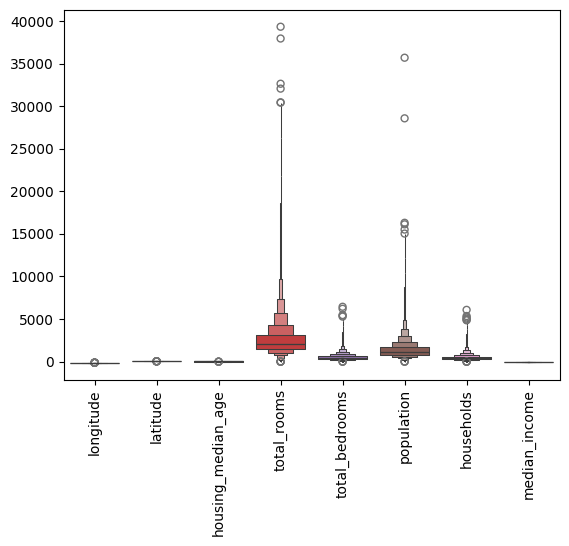

In [ ]:
sns.boxenplot(X[num_cols])
plt.xticks(rotation=90)
plt.show()

### IQR

In [ ]:
for col in num_cols:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1

    lower=Q1 - 1.5 *IQR
    upper=Q3 + 1.5 *IQR

    outlier=df[(df[col]<lower) | (df[col]>upper)]

    print('\n',col)
    print('lower: ',lower)
    print('upper: ',upper)
    print('Outlier: ',len(outlier))


 longitude
lower:  -127.48499999999999
upper:  -112.32500000000002
Outlier:  0

 latitude
lower:  28.259999999999998
upper:  43.38
Outlier:  0

 housing_median_age
lower:  -10.5
upper:  65.5
Outlier:  0

 total_rooms
lower:  -1102.625
upper:  5698.375
Outlier:  1287

 total_bedrooms
lower:  -230.5
upper:  1173.5
Outlier:  1271

 population
lower:  -620.0
upper:  3132.0
Outlier:  1196

 households
lower:  -207.5
upper:  1092.5
Outlier:  1220

 median_income
lower:  -0.7063750000000004
upper:  8.013024999999999
Outlier:  681


In [ ]:
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,train_size=0.8,random_state=42)

In [ ]:
num_pipeline =Pipeline(
    steps=[
        ('imputer',SimpleImputer()),
        ('scaling',RobustScaler())
    ]
)

In [ ]:
preprocess=ColumnTransformer(
    transformers=[
        ('nums',num_pipeline,num_cols),
        ('encoding',OneHotEncoder(handle_unknown='ignore'),['ocean_proximity'])
    ]
)

In [ ]:
main_pipe=Pipeline(
    steps=[
        ('preprocess',preprocess),
        ('model',KNeighborsRegressor())
    ]
) 

In [ ]:
main_pipe.fit(Xtrain,ytrain) 

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('nums', ...), ('encoding', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
ypred_train=main_pipe.predict(Xtrain)
ypred_test=main_pipe.predict(Xtest)

In [ ]:
print('Training: ')
print('r2_score: ',r2_score(ytrain,ypred_train))
print('MAE: ',mean_absolute_error(ytrain,ypred_train))
print('RMSE: ',root_mean_squared_error(ytrain,ypred_train))

Training: 
r2_score:  0.813918748485106
MAE:  33600.144040697676
RMSE:  49874.779462932835


In [ ]:
print('Testing: ')
print('r2_score: ',r2_score(ytest,ypred_test))
print('MAE: ',mean_absolute_error(ytest,ypred_test))
print('RMSE: ',root_mean_squared_error(ytest,ypred_test))

Testing: 
r2_score:  0.7002619657178628
MAE:  42200.358527131786
RMSE:  62672.115908399894


### Random Forest

In [ ]:
main_pipe_RF=Pipeline(
    steps=[
        ('preprocessor',preprocess),
        ('model',RandomForestRegressor())
    ]

)

In [ ]:
grid_cv=GridSearchCV(
    estimator=main_pipe_RF,
    param_grid=[
        {
            'model__criterion':['squared_error', 'absolute_error'],
            'model__max_depth':[10,15],
            'model__min_samples_split':[5],
            'model__min_samples_leaf':[2],
            'model__random_state':[42],
            'model__n_jobs':[-1]
        }
    ],
    n_jobs=-1
)

In [ ]:
grid_cv.fit(Xtrain,ytrain)

In [ ]:
ypred_train_RF=main_pipe_RF.predict(Xtrain)
ypred_test_RF=main_pipe_RF.predict(Xtest)

In [ ]:
print('Training: ')
print('r2_score: ',r2_score(ytrain,ypred_train_RF))
print('MAE: ',mean_absolute_error(ytrain,ypred_train_RF))
print('RMSE: ',root_mean_squared_error(ytrain,ypred_train_RF))

Training: 
r2_score:  0.9755836607142432
MAE:  11633.997050629843
RMSE:  18066.330664763664


In [ ]:
print('Testing: ')
print('r2_score: ',r2_score(ytest,ypred_test_RF))
print('MAE: ',mean_absolute_error(ytest,ypred_test_RF))
print('RMSE: ',root_mean_squared_error(ytest,ypred_test_RF))

Testing: 
r2_score:  0.8170274317031665
MAE:  31623.509944282945
RMSE:  48966.20224889478
